In [262]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [263]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA

In [264]:
df.shape

(1338, 7)

In [265]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [266]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [267]:
df.isnull().count()

age         1338
sex         1338
bmi         1338
children    1338
smoker      1338
region      1338
charges     1338
dtype: int64

In [268]:
numerical_columns = df.select_dtypes(include=["number"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns
numerical_columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

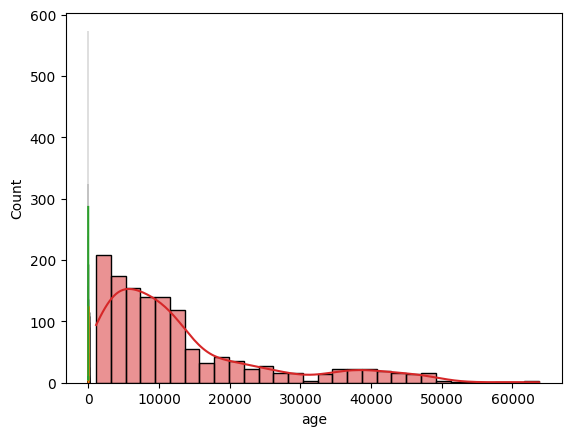

In [269]:
for i in numerical_columns:
    sns.histplot(df[i], kde=True)
    # plt.show()

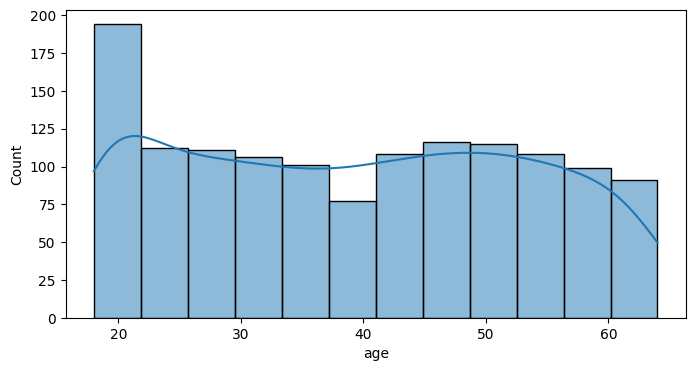

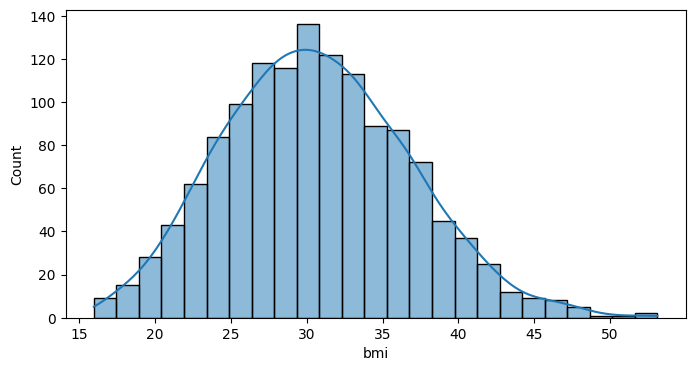

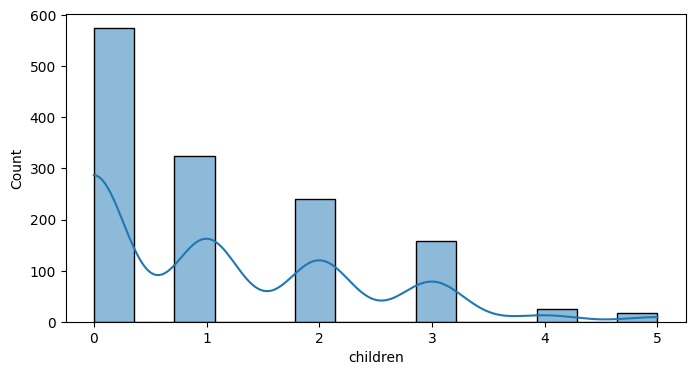

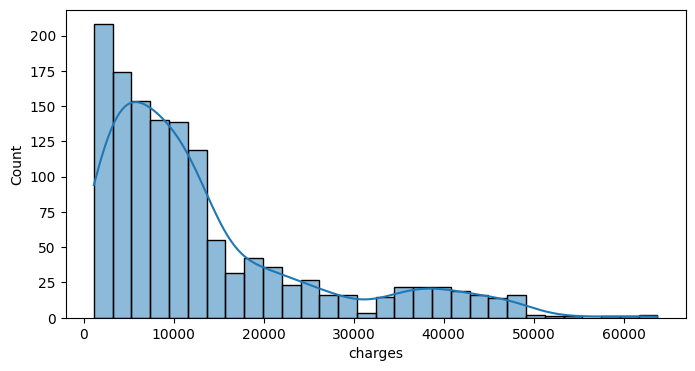

In [270]:
for i in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[i], kde=True)

In [271]:
categorical_columns

Index(['sex', 'smoker', 'region'], dtype='object')

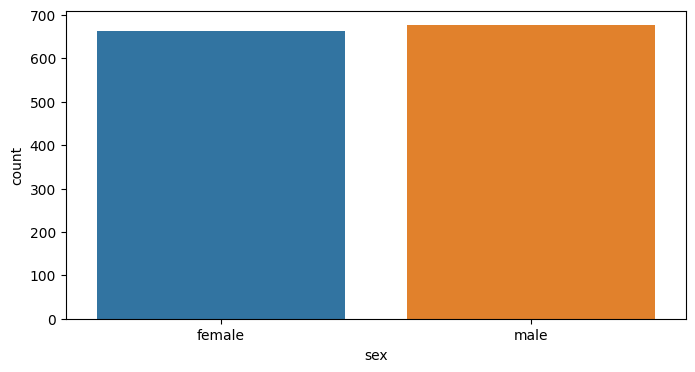

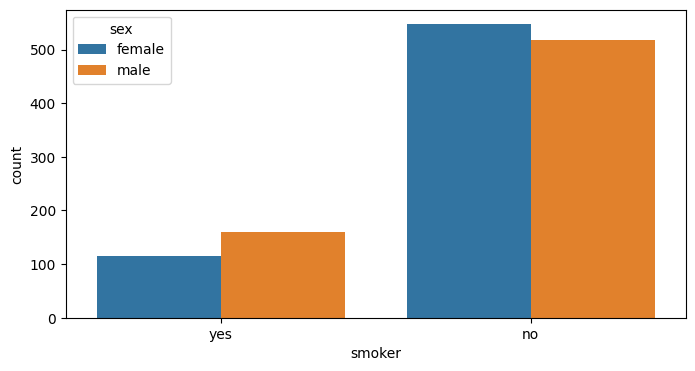

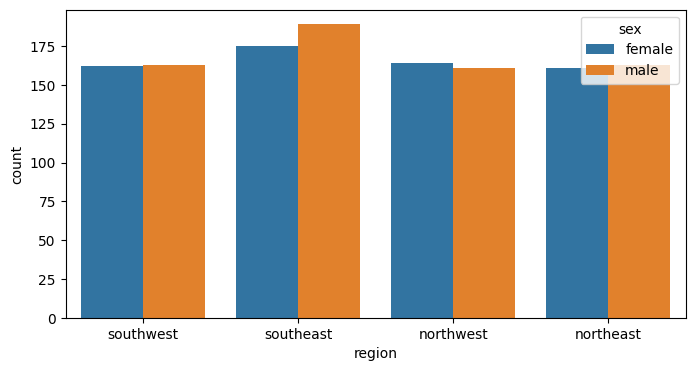

In [272]:
for i in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[i], hue=df["sex"])

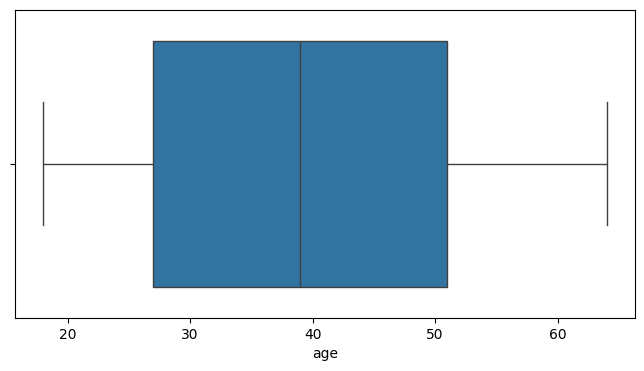

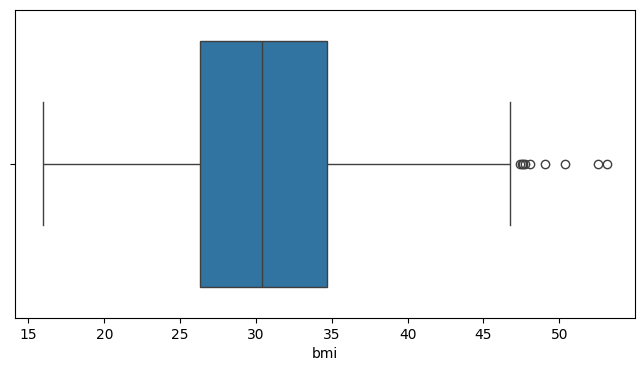

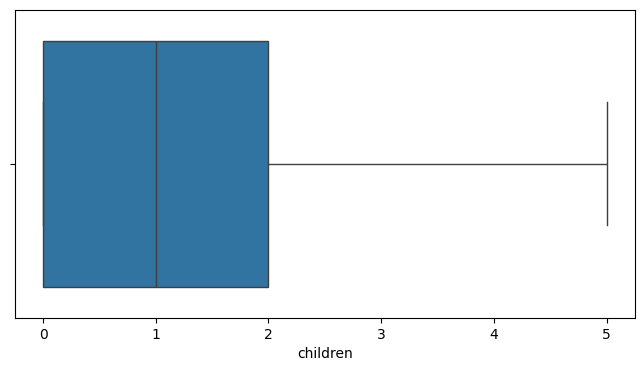

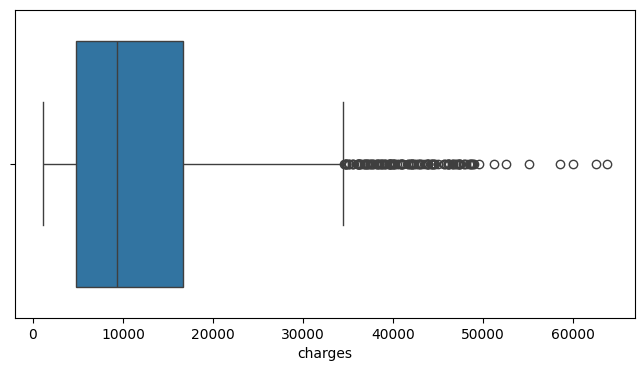

In [273]:
for i in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[i])

In [274]:
df['children'].quantile([0.25, 0.75])

0.25    0.0
0.75    2.0
Name: children, dtype: float64

<Axes: >

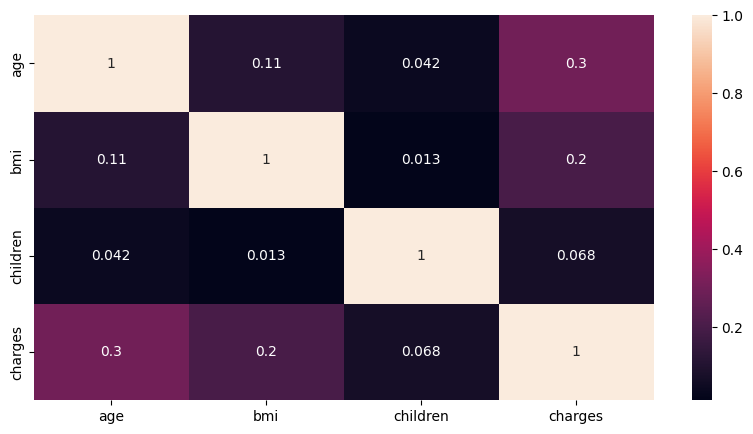

In [275]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Data cleaning and preprocessing


In [276]:
df_clean = df.copy()
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [277]:
df_clean.shape

(1338, 7)

In [278]:
df_clean.drop_duplicates(inplace=True)
df_clean.shape

(1337, 7)

In [279]:
df_clean.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [280]:
df_clean.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [281]:
df_clean_object = df_clean.select_dtypes(include=["object"]).columns
df_clean_number = df_clean.select_dtypes(include=["number"]).columns
df_clean_object

Index(['sex', 'smoker', 'region'], dtype='object')

In [282]:
df_clean.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [283]:
df_clean['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [284]:
df_clean['sex'] = df_clean['sex'].map({'male': 0, 'female': 1})
df_clean['smoker'] = df_clean['smoker'].map({'no': 0, 'yes': 1})
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [285]:
df_clean.rename(columns={'sex': 'is_female', 'smoker': 'is_smoker'}, inplace=True)
df_clean.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [286]:
df_clean['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [287]:
# df_clean['region'] = df_clean['region'].map({'southwest': 0, 'southeast': 1, 'northwest': 2, 'northeast': 3})
# df_clean.head()

In [288]:
df_clean = pd.get_dummies(df_clean, columns=['region'])
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


In [289]:
bool_col = df_clean.select_dtypes(include=["bool"]).columns
df_clean[bool_col] = df_clean[bool_col].astype(int)
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0


# Feature engineering and extraction

<Axes: xlabel='bmi', ylabel='Count'>

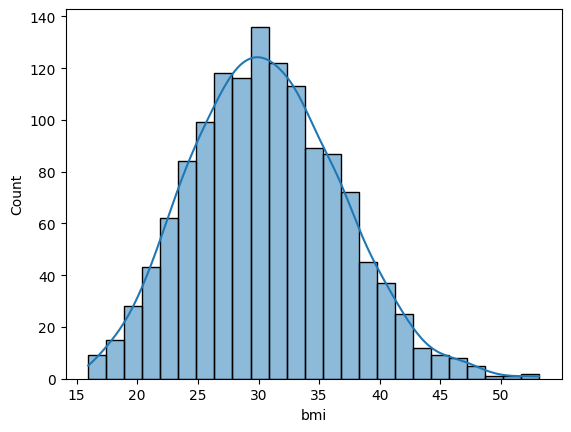

In [290]:
sns.histplot(df['bmi'], kde=True)

In [291]:
df_clean['bmi_category'] = pd.cut(df_clean['bmi'], bins=[0, 18.5, 24.9, 29.9, np.inf], labels=['underweight', 'normalweight', 'overweight', 'obese'])
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,0,0,0,1,overweight
1,18,0,33.770,1,0,1725.55230,0,0,1,0,obese
2,28,0,33.000,3,0,4449.46200,0,0,1,0,obese
3,33,0,22.705,0,0,21984.47061,0,1,0,0,normalweight
4,32,0,28.880,0,0,3866.85520,0,1,0,0,overweight


In [292]:
df_clean = pd.get_dummies(df_clean, columns=['bmi_category'])
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normalweight,bmi_category_overweight,bmi_category_obese
0,19,1,27.900,0,1,16884.92400,0,0,0,1,False,False,True,False
1,18,0,33.770,1,0,1725.55230,0,0,1,0,False,False,False,True
2,28,0,33.000,3,0,4449.46200,0,0,1,0,False,False,False,True
3,33,0,22.705,0,0,21984.47061,0,1,0,0,False,True,False,False
4,32,0,28.880,0,0,3866.85520,0,1,0,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0,False,False,False,True
1334,18,1,31.920,0,0,2205.98080,1,0,0,0,False,False,False,True
1335,18,1,36.850,0,0,1629.83350,0,0,1,0,False,False,False,True
1336,21,1,25.800,0,0,2007.94500,0,0,0,1,False,False,True,False


In [293]:
bool_col = df_clean.select_dtypes(include=["bool"]).columns
df_clean[bool_col] = df_clean[bool_col].astype(int)
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normalweight,bmi_category_overweight,bmi_category_obese
0,19,1,27.900,0,1,16884.92400,0,0,0,1,0,0,1,0
1,18,0,33.770,1,0,1725.55230,0,0,1,0,0,0,0,1
2,28,0,33.000,3,0,4449.46200,0,0,1,0,0,0,0,1
3,33,0,22.705,0,0,21984.47061,0,1,0,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0,0,0,0,1
1334,18,1,31.920,0,0,2205.98080,1,0,0,0,0,0,0,1
1335,18,1,36.850,0,0,1629.83350,0,0,1,0,0,0,0,1
1336,21,1,25.800,0,0,2007.94500,0,0,0,1,0,0,1,0


<Axes: >

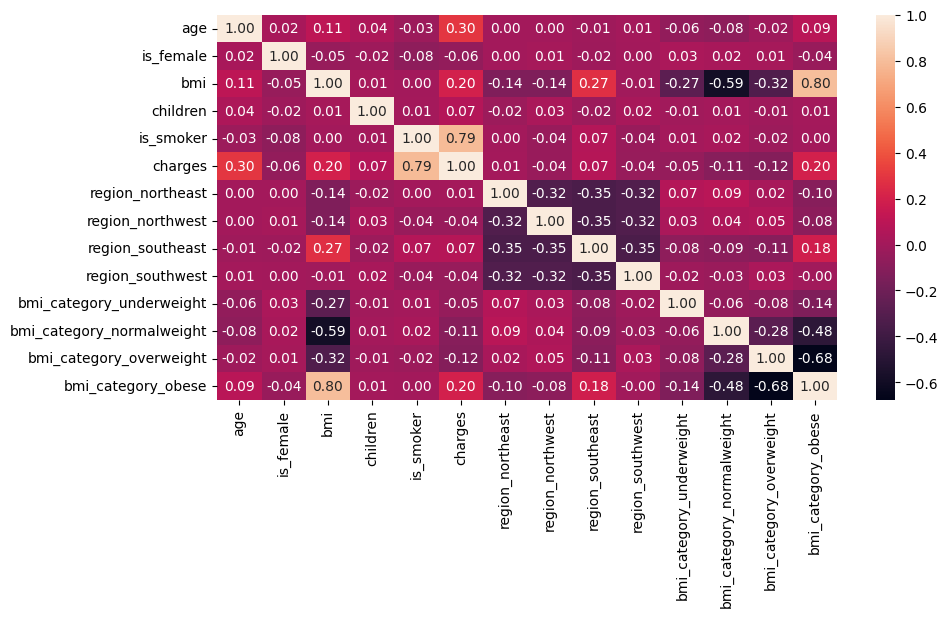

In [294]:
plt.figure(figsize=(10, 5))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, fmt=".2f")

In [295]:
df_clean.corr(numeric_only=True)['charges'].sort_values(ascending=False)

charges                      1.000000
is_smoker                    0.787234
age                          0.298308
bmi                          0.198401
bmi_category_obese           0.197659
region_southeast             0.073578
children                     0.067389
region_northeast             0.005945
region_northwest            -0.038695
region_southwest            -0.043637
bmi_category_underweight    -0.048225
is_female                   -0.058044
bmi_category_normalweight   -0.105655
bmi_category_overweight     -0.118279
Name: charges, dtype: float64

<Axes: >

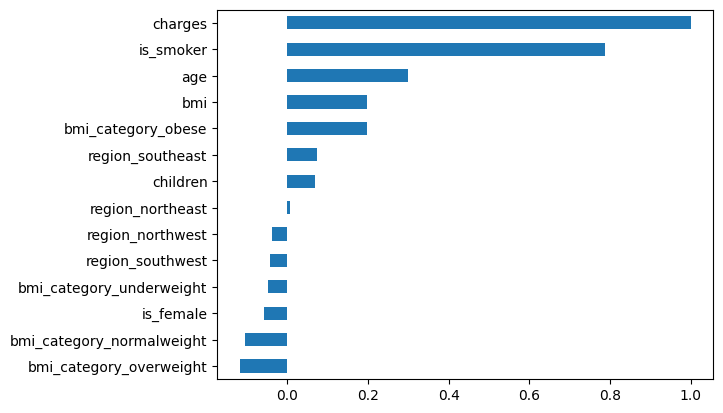

In [296]:
df_clean.corr(numeric_only=True)['charges'].sort_values().plot(kind='barh')

In [297]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normalweight,bmi_category_overweight,bmi_category_obese
0,19,1,27.900,0,1,16884.92400,0,0,0,1,0,0,1,0
1,18,0,33.770,1,0,1725.55230,0,0,1,0,0,0,0,1
2,28,0,33.000,3,0,4449.46200,0,0,1,0,0,0,0,1
3,33,0,22.705,0,0,21984.47061,0,1,0,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0,0,0,0,1
1334,18,1,31.920,0,0,2205.98080,1,0,0,0,0,0,0,1
1335,18,1,36.850,0,0,1629.83350,0,0,1,0,0,0,0,1
1336,21,1,25.800,0,0,2007.94500,0,0,0,1,0,0,1,0


In [298]:
from sklearn.model_selection import train_test_split
X = df_clean.drop('charges', axis=1)
y = df_clean['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [299]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [300]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [301]:
y_pred = model.predict(X_test)
y_pred

array([ 8165.93791076,  5264.01712303, 14492.93605754, 32412.34632566,
        8892.41139086, 13251.93939913, 30611.47884684,   973.16907743,
       11129.62557559, 10122.658709  , 10583.43181057, 32185.93702475,
       31982.97668995, 15685.99596334, 10623.58713093,  8324.29243282,
        5172.32448297, 32378.51143932,  2940.99656937,  3991.93967533,
        4706.20589352, 29314.25635852, 13730.48343392, 29332.25738629,
       31424.5337944 ,  6336.38038385, 34876.44885975, 37523.56993008,
       12924.69478036, 14653.06865599,  7974.0334163 , 12919.84212125,
         422.08946535, 11130.46474852, 37328.74131764, 12956.2212018 ,
        3591.45049366,  4481.99090708, 31358.8056361 ,  8050.7214411 ,
        6479.80281037, 30680.43263882, 35249.72614637, 13491.17507977,
        7879.74438154,  2866.34326582,  5534.09935066,  7440.47916498,
        3691.74993513, 10362.58694513,  7760.05687205, 10849.64286507,
       30861.87752691,  4681.93097802, 11362.7253185 , 11457.47595027,
      

Note: R2 only

In [302]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
r2

0.8027245690414588

absolute R2

In [303]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adjusted_r2

0.7926277950160217

In [304]:
from xgboost import XGBRegressor
model_xg = XGBRegressor()
model_xg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [305]:
y_pred_xg = model_xg.predict(X_test)
y_pred_xg

array([ 8146.839  ,  6782.149  , 11775.749  , 38992.24   ,  4501.0376 ,
        9219.41   , 37806.695  ,  1212.0406 , 11307.69   ,  9991.701  ,
       13573.985  , 27926.613  , 39065.07   , 18819.826  , 11381.474  ,
        8805.569  , 14486.739  , 39108.16   ,  3852.142  ,  4039.612  ,
       11903.033  , 21364.357  ,  9494.571  , 20925.846  , 38329.793  ,
       18773.955  , 42776.83   , 46646.55   , 10967.929  , 18476.518  ,
        5405.0933 ,  8279.413  ,  1037.099  , 12423.567  , 47602.61   ,
        7659.233  ,  8814.963  ,  5418.736  , 23427.898  ,  9215.439  ,
        1968.7782 , 20815.992  , 39989.676  , 10901.133  ,  8009.612  ,
        3338.4858 ,  2834.315  ,  7812.1597 ,  6258.8813 , 14308.726  ,
        5347.3584 ,  4010.9043 , 21839.059  ,  8061.6484 ,  8075.8076 ,
       10080.773  ,  9774.511  ,  4029.8826 , 41412.24   ,  8895.111  ,
        9623.316  ,  4833.8667 , 13561.662  ,  1907.1183 , 12029.826  ,
       16287.483  ,  4661.7466 , 24780.088  , 16246.388  , 15313

In [306]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [307]:
model_xg.score(X_test, y_test)        #r2_score

0.8589871284468448

In [308]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xg)
mse = mean_squared_error(y_test, y_pred_xg)
rmse = mean_squared_error(y_test, y_pred_xg) ** 0.5
r2 = r2_score(y_test, y_pred_xg)
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

In [309]:
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")

MAE: 2984.84
MSE: 25911970.26
RMSE: 5090.38
R² Score: 0.8590
Adjusted R²: 0.8518


GridSearchCV

In [310]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search_xg = GridSearchCV(model_xg, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=2)
grid_search_xg.fit(X, y)

best_params = grid_search_xg.best_params_
best_score = grid_search_xg.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END 

In [311]:
result_xg = pd.DataFrame(grid_search_xg.cv_results_)
result_xg

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_learning_rate,param_max_depth,param_n_estimators,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.020771,0.002746,0.003432,0.001115,0.8,0.01,3,100,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.699047,0.654028,0.676119,0.678022,0.684513,0.678346,0.014581,104
1,0.021082,0.004615,0.003565,0.001129,0.8,0.01,3,100,1.0,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.699924,0.655697,0.677502,0.677731,0.686818,0.679534,0.014453,103
2,0.028025,0.005721,0.003049,0.000722,0.8,0.01,3,200,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.849412,0.787779,0.837863,0.817850,0.833787,0.825338,0.021329,58
3,0.025029,0.004301,0.003297,0.000936,0.8,0.01,3,200,1.0,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.848814,0.788250,0.838992,0.816970,0.835472,0.825700,0.021378,55
4,0.039334,0.006475,0.003572,0.001426,0.8,0.01,3,300,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.878049,0.809968,0.876024,0.844329,0.862371,0.854148,0.025162,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,0.045385,0.007161,0.004526,0.001682,1.0,0.20,7,100,1.0,"{'colsample_bytree': 1.0, 'learning_rate': 0.2...",0.810306,0.748877,0.859652,0.802605,0.838555,0.811999,0.037554,74
104,0.071641,0.016351,0.003824,0.001561,1.0,0.20,7,200,0.8,"{'colsample_bytree': 1.0, 'learning_rate': 0.2...",0.809351,0.733089,0.835976,0.819166,0.836633,0.806843,0.038299,82
105,0.063454,0.006484,0.003706,0.000827,1.0,0.20,7,200,1.0,"{'colsample_bytree': 1.0, 'learning_rate': 0.2...",0.802284,0.738367,0.849524,0.800050,0.833643,0.804774,0.038143,88
106,0.079546,0.007928,0.003309,0.000213,1.0,0.20,7,300,0.8,"{'colsample_bytree': 1.0, 'learning_rate': 0.2...",0.808326,0.731878,0.835650,0.818883,0.835354,0.806018,0.038487,84


In [312]:
result_xg[["mean_test_score"]].sort_values(by="mean_test_score", ascending=False)

,mean_test_score
58,0.860303
59,0.859962
73,0.859171
19,0.859077
72,0.858209
...,...
0,0.678346
7,0.677858
6,0.676608
12,0.669145


import joblib


In [313]:
import joblib
joblib.dump(model_xg, "xgb_model.joblib")
joblib.dump(X.columns.tolist(), "columns.joblib")
joblib.dump(scaler, "scaler.joblib")


['scaler.joblib']